In [1]:
import pandas as pd
import matplotlib.pyplot as plt



Top 10 Highest-Emission Ingredients (kg CO₂-eq per kg):

Beef (beef herd): 99.48
Dark Chocolate: 46.65
Lamb & Mutton: 39.72
Beef (dairy herd): 33.30
Coffee: 28.53
Prawns (farmed): 26.87
Cheese: 23.88
Fish (farmed): 13.63
Pig Meat: 12.31
Poultry Meat: 9.87


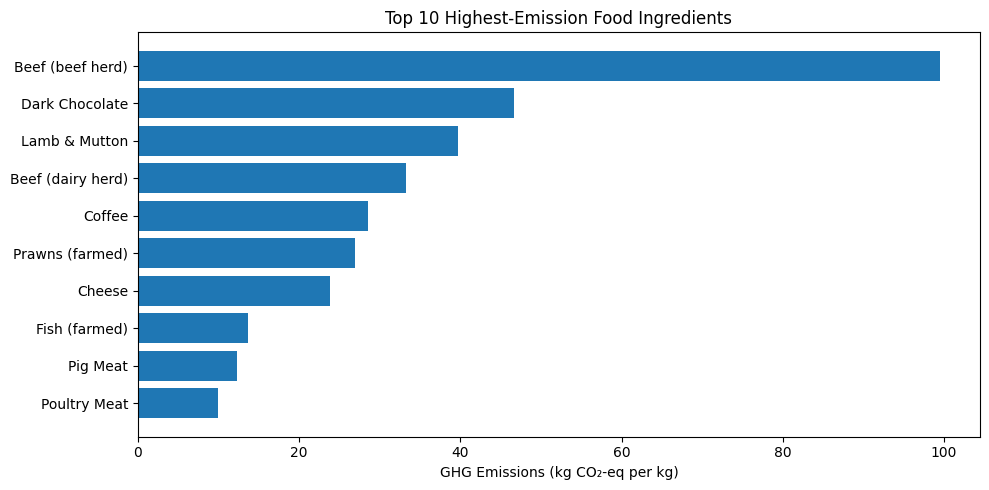

In [2]:

# ============================
# LOAD DATASET A
# ============================
DATASET_PATH = r"D:\Y4 Research\datasets\greenhouse-gas-emissions-per-kilogram-of-food-product\greenhouse-gas-emissions-per-kilogram-of-food-product.csv"
df = pd.read_csv(DATASET_PATH)

# ----------------------------
# COLUMN DETECTION (ROBUST)
# ----------------------------
# Try to detect emission column automatically
emission_col = None
for col in df.columns:
    if "emission" in col.lower() or "ghg" in col.lower():
        emission_col = col
        break

if emission_col is None:
    raise ValueError("Could not find an emission column in the dataset.")

# Try to detect ingredient / food name column
name_col = None
for col in df.columns:
    if col.lower() in ["entity", "food", "food product", "product"]:
        name_col = col
        break

if name_col is None:
    name_col = df.columns[0]  # fallback to first column

# ============================
# CLEAN & SORT
# ============================
df_clean = df[[name_col, emission_col]].dropna()
df_clean = df_clean.sort_values(emission_col, ascending=False)

# Select top N high-impact ingredients
TOP_N = 10
top_emitters = df_clean.head(TOP_N)

# ============================
# PRINT FINDINGS
# ============================
print(f"\nTop {TOP_N} Highest-Emission Ingredients (kg CO₂-eq per kg):\n")
for i, row in top_emitters.iterrows():
    print(f"{row[name_col]}: {row[emission_col]:.2f}")

# ============================
# PLOT: RANKED BAR CHART
# ============================
plt.figure(figsize=(10, 5))
plt.barh(
    top_emitters[name_col][::-1],
    top_emitters[emission_col][::-1]
)
plt.xlabel("GHG Emissions (kg CO₂-eq per kg)")
plt.title(f"Top {TOP_N} Highest-Emission Food Ingredients")
plt.tight_layout()
plt.show()


Detected stage columns:
Farm: Land use change
Processing: Processing
Transport: Transport
Retail: Retail

Production Stage Contribution (%):
            Total Emissions  Percentage
Farm                   54.2       70.85
Processing             10.9       14.25
Transport               8.4       10.98
Retail                  3.0        3.92


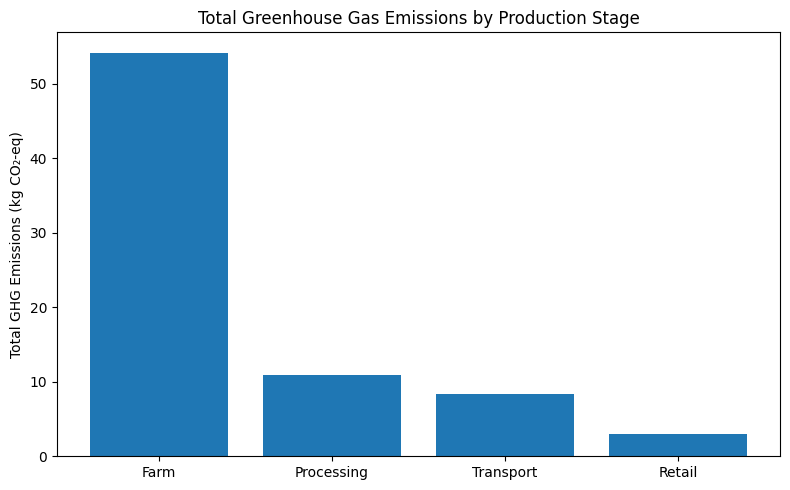

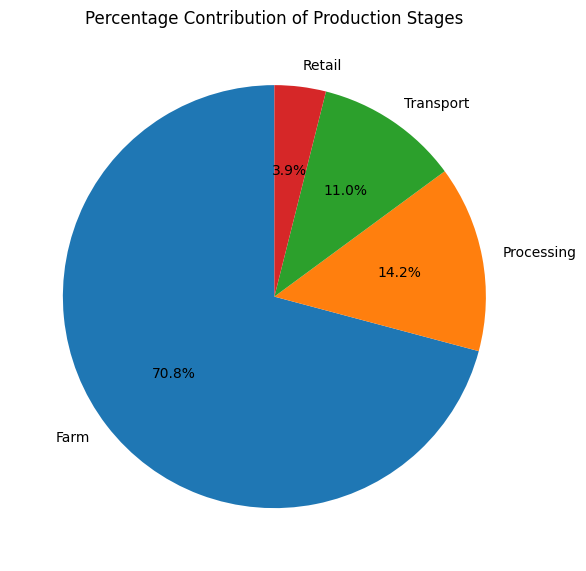

In [3]:
# ============================
# LOAD DATASET B
# ============================
DATASET_PATH = r"D:\Y4 Research\datasets\Food_Production.csv"
df = pd.read_csv(DATASET_PATH)

# ============================
# IDENTIFY STAGE COLUMNS
# ============================
stage_keywords = {
    "Farm": ["farm", "agriculture", "land"],
    "Processing": ["process"],
    "Transport": ["transport"],
    "Packaging": ["packag"],
    "Retail": ["retail"]
}

stage_cols = {}

for stage, keywords in stage_keywords.items():
    for col in df.columns:
        if any(k in col.lower() for k in keywords):
            stage_cols[stage] = col
            break

if len(stage_cols) < 2:
    raise ValueError("Could not identify sufficient production stage columns.")

print("Detected stage columns:")
for k, v in stage_cols.items():
    print(f"{k}: {v}")

# ============================
# AGGREGATE EMISSIONS
# ============================
stage_totals = {}

for stage, col in stage_cols.items():
    stage_totals[stage] = df[col].sum(skipna=True)

stage_df = pd.DataFrame.from_dict(
    stage_totals, orient="index", columns=["Total Emissions"]
)

# ============================
# PERCENTAGE CONTRIBUTION
# ============================
stage_df["Percentage"] = (
    stage_df["Total Emissions"] / stage_df["Total Emissions"].sum()
) * 100

print("\nProduction Stage Contribution (%):")
print(stage_df.round(2))

# ============================
# STACKED BAR CHART
# ============================
plt.figure(figsize=(8, 5))
plt.bar(
    stage_df.index,
    stage_df["Total Emissions"]
)
plt.ylabel("Total GHG Emissions (kg CO₂-eq)")
plt.title("Total Greenhouse Gas Emissions by Production Stage")
plt.tight_layout()
plt.show()

# ============================
# PERCENTAGE CONTRIBUTION CHART
# ============================
plt.figure(figsize=(6, 6))
plt.pie(
    stage_df["Percentage"],
    labels=stage_df.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage Contribution of Production Stages")
plt.tight_layout()
plt.show()
